# Cost Sensitivity for the §16.4 ETF Baseline

**Docker image**: `ml4t`

Section 16.6 argues that a credible backtest reports gross and net performance,
turnover, break-even cost, and the sensitivity of the headline metrics to the
cost assumption. This notebook implements that diagnostic on the §16.4 ETF
momentum baseline. Same universe, same protocol, same simulator as NB01 — only
the per-leg fee changes.

**Learning objectives**

1. Quantify the gross-to-net Sharpe gap at the §16.4 protocol's 5 bp/leg
   assumption.
2. Sweep the per-leg fee across a plausible range and read the resulting
   Sharpe / CAGR / drawdown curve.
3. Compute the **break-even cost** at which gross return equals zero — the
   quantity that tells you how much error in the cost estimate the strategy
   can absorb.
4. Read **annualized turnover** as the multiplier that translates per-leg
   cost into annual return drag.

**Book reference**: Chapter 16, §16.6 (Diagnosing the Economic Value).
**Prerequisites**: §16.4 baseline (NB01); the helper `_etf_baseline.py`
reproduces its returns and weights.

In [1]:
"""§16.6 cost-sensitivity diagnostic on the §16.4 ETF momentum baseline."""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from _etf_baseline import (
    DEFAULT_FEES,
    annualized_turnover,
    load_panel,
    metrics,
    momentum_weights,
    simulate,
)
from ml4t.diagnostic.visualization.backtest.cost_attribution import (
    plot_cost_sensitivity,
    plot_cost_waterfall,
)

In [2]:
# Production defaults — Papermill injects overrides for CI
START_DATE = "2010-01-01"
END_DATE = "2024-01-01"
COST_GRID_BP = [0, 1, 2, 5, 10, 15, 25, 40, 60, 100, 150, 200]

## 1. Build the §16.4 Baseline Once

The baseline weights are independent of the cost assumption: the strategy
selects the same ETFs in the same months regardless of fees. We therefore
build the weights once and feed them into the simulator under each cost
assumption.

In [3]:
panel = load_panel(START_DATE, END_DATE)
weights = momentum_weights(panel)

# Reference (zero-cost) simulation — used for break-even and turnover
result_gross = simulate(panel.prices, weights, fees=0.0)
turnover_2way = annualized_turnover(result_gross)
gross = metrics(result_gross.equity)
print(
    f"Gross (zero-cost): CAGR={gross['cagr'] * 100:.2f}%  "
    f"Sharpe={gross['sharpe']:.2f}  MaxDD={gross['max_drawdown'] * 100:.1f}%"
)
print(f"Annualized 2-way turnover: {turnover_2way * 100:.0f}% (sum |trades| / mean equity / years)")

Gross (zero-cost): CAGR=7.67%  Sharpe=0.68  MaxDD=-31.7%
Annualized 2-way turnover: 463% (sum |trades| / mean equity / years)


## 2. Sweep the Cost Grid

At each per-leg fee we re-simulate and record the same metric set used in
§16.5: total return, CAGR, vol, Sharpe, max drawdown. The 5 bp row matches
Table 16.4's net result exactly because the simulator and weights are
identical to NB01.

In [4]:
rows = []
for bp in COST_GRID_BP:
    res = simulate(panel.prices, weights, fees=bp / 10_000)
    m = metrics(res.equity)
    rows.append(
        {
            "cost_bp_per_leg": bp,
            "cagr": m["cagr"],
            "vol": m["vol"],
            "sharpe": m["sharpe"],
            "max_dd": m["max_drawdown"],
            "total_return": m["total_return"],
        }
    )
sweep = pd.DataFrame(rows)
sweep

,cost_bp_per_leg,cagr,vol,sharpe,max_dd,total_return
0,0,0.076660,0.113497,0.675436,-0.316993,1.806787
1,1,0.076143,0.113510,0.670799,-0.317314,1.787999
2,2,0.075625,0.113524,0.666161,-0.317635,1.769333
3,5,0.074074,0.113568,0.652248,-0.318598,1.714059
4,10,0.071492,0.113650,0.629059,-0.320202,1.624302
5,15,0.068914,0.113742,0.605876,-0.321804,1.537423
6,25,0.063767,0.113960,0.559555,-0.325003,1.371942
7,40,0.056072,0.114367,0.490279,-0.329791,1.143142
8,60,0.045859,0.115061,0.398564,-0.336154,0.871048
9,100,0.025580,0.116959,0.218711,-0.348811,0.423215


## 3. Break-Even Cost

The first-order approximation is

$$\text{break-even}_{\text{bp/leg}} \approx \frac{\text{gross CAGR}}
                                                  {\text{annual turnover}} \times 10{,}000.$$

Above this per-leg fee the strategy's net CAGR turns negative on this sample.
Treat the break-even as a fragility ceiling, not as a target.

In [5]:
break_even_bp = gross["cagr"] / turnover_2way * 10_000
print(f"Break-even cost (approx): {break_even_bp:.0f} bp per leg")
print(f"§16.4 protocol cost:       {DEFAULT_FEES * 10_000:.0f} bp per leg")
print(f"Headroom multiplier:       {break_even_bp / (DEFAULT_FEES * 10_000):.0f}x")

Break-even cost (approx): 166 bp per leg
§16.4 protocol cost:       5 bp per leg
Headroom multiplier:       33x


A high headroom multiplier sounds reassuring, but two caveats apply.

- The break-even uses *gross* return; small misestimates compound across
  many trades and the realized cost can also include slippage and
  spread-cost, not just commission.
- The diagnostic is path-blind. A strategy with the same gross CAGR but
  front-loaded turnover may still be fragile if costs are above average in
  the years that contributed most of the return.

## 4. Sensitivity Curve

Plot Sharpe and CAGR as a function of per-leg cost. The slope of these
curves at the §16.4 operating point is the marginal cost elasticity —
how much performance you lose per additional basis point.

/tmp/ipykernel_1949241/2706184777.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


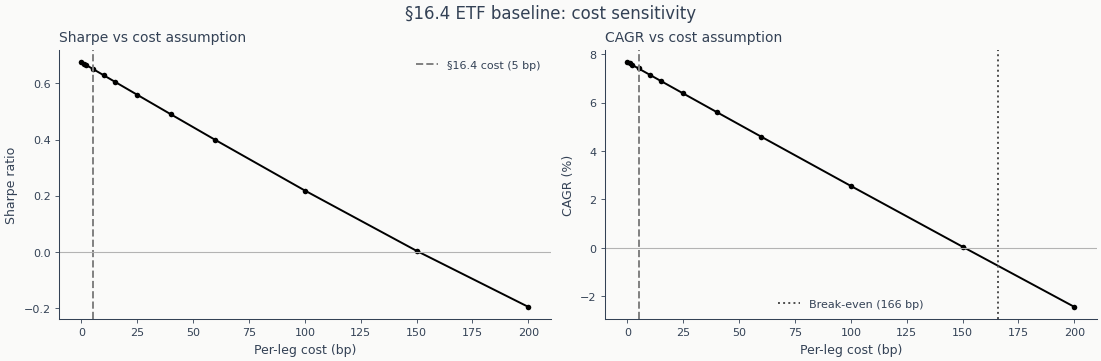

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)

axes[0].plot(sweep["cost_bp_per_leg"], sweep["sharpe"], color="black", marker="o")
axes[0].axvline(DEFAULT_FEES * 10_000, color="0.5", linestyle="--", label="§16.4 cost (5 bp)")
axes[0].axhline(0, color="0.7", linewidth=0.8)
axes[0].set_xlabel("Per-leg cost (bp)")
axes[0].set_ylabel("Sharpe ratio")
axes[0].set_title("Sharpe vs cost assumption", loc="left")
axes[0].legend(frameon=False)

axes[1].plot(sweep["cost_bp_per_leg"], sweep["cagr"] * 100, color="black", marker="o")
axes[1].axvline(DEFAULT_FEES * 10_000, color="0.5", linestyle="--")
axes[1].axhline(0, color="0.7", linewidth=0.8)
axes[1].axvline(
    break_even_bp, color="0.3", linestyle=":", label=f"Break-even ({break_even_bp:.0f} bp)"
)
axes[1].set_xlabel("Per-leg cost (bp)")
axes[1].set_ylabel("CAGR (%)")
axes[1].set_title("CAGR vs cost assumption", loc="left")
axes[1].legend(frameon=False)

fig.suptitle("§16.4 ETF baseline: cost sensitivity", fontsize=12)
fig.show()

## 5. Cost Drag Decomposition

Annual return drag from costs is approximately

$$\text{drag}_{\text{annual}} \approx
  \text{turnover}_{\text{2-way}} \times \text{fee}_{\text{per leg}}.$$

At the §16.4 protocol's 5 bp fee and the strategy's measured turnover, this
matches the gap between the gross and net CAGR closely — the simulator and
the back-of-envelope estimate agree to within rounding.

In [7]:
fee_bp = DEFAULT_FEES * 10_000
estimated_drag_pct = turnover_2way * DEFAULT_FEES * 100
realized_drag_pct = (
    gross["cagr"] - sweep.loc[sweep["cost_bp_per_leg"] == fee_bp, "cagr"].iloc[0]
) * 100
print(f"Estimated drag at {fee_bp:.0f} bp: {estimated_drag_pct:.2f}% / yr")
print(f"Realized drag at {fee_bp:.0f} bp:  {realized_drag_pct:.2f}% / yr")

Estimated drag at 5 bp: 0.23% / yr
Realized drag at 5 bp:  0.26% / yr


## 6. Library Equivalents — `ml4t-diagnostic`

Sections 4 and 5 build the cost diagnostic from the equity curve so the
mechanics are explicit. `ml4t-diagnostic` ships the same two views as
one-call helpers, useful when the goal is a backtest report rather than a
teaching artifact:

- `plot_cost_waterfall` decomposes gross PnL into commission and slippage
  bars at the §16.4 operating cost.
- `plot_cost_sensitivity` reproduces the §4 Sharpe-vs-cost curve directly
  from the gross daily-return series, with a break-even annotation.

Both are plotly figures and slot into the report bundle that
`09_performance_reporting` assembles for the same backtest.

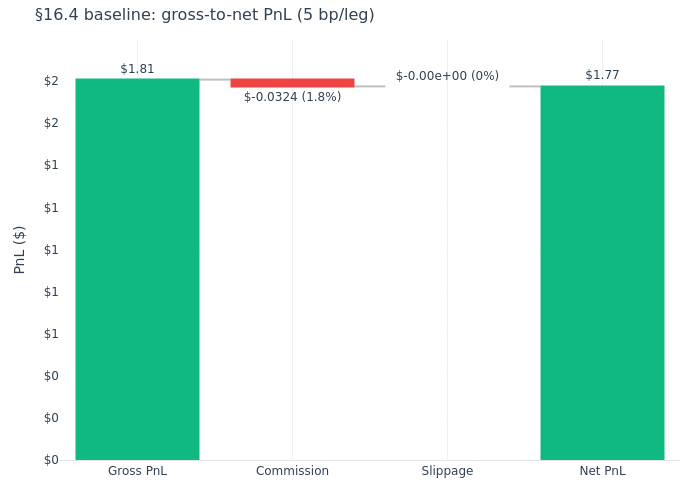

In [8]:
# Cumulative gross PnL over the sample, as a fraction of starting equity.
# `commission_frac` below is built as turnover × fees × years and is already
# dimensionless (turnover = dollar_turnover / mean_equity / years), so
# `gross_pnl` must be expressed in the same units for the waterfall bars to
# compare. The previous form `equity[-1] - equity[0]` returned dollars and
# made the commission bar invisible by ~equity[0] (~10⁵).
gross_pnl_frac = float(result_gross.equity.iloc[-1] / result_gross.equity.iloc[0] - 1.0)
# At the §16.4 operating cost, all cost is commission (no modeled slippage).
sample_years = (panel.prices.index[-1] - panel.prices.index[0]).days / 365.25
commission_frac = float(turnover_2way * DEFAULT_FEES * sample_years)

waterfall = plot_cost_waterfall(
    gross_pnl=gross_pnl_frac,
    commission=commission_frac,
    slippage=0.0,
    title=f"§16.4 baseline: gross-to-net PnL ({DEFAULT_FEES * 10_000:.0f} bp/leg)",
)
waterfall.show()

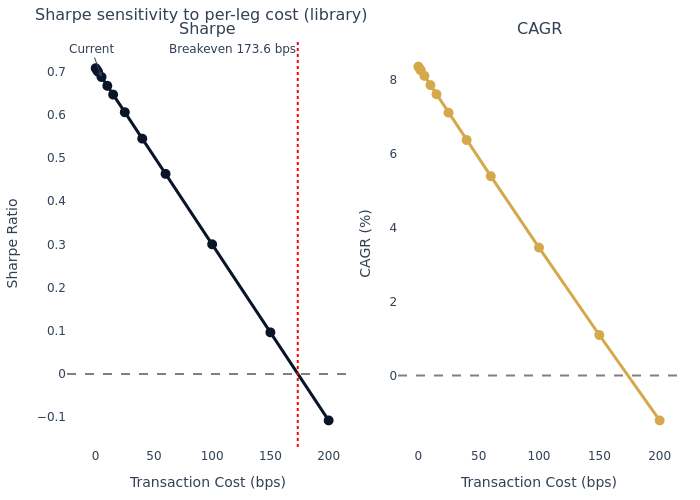

In [9]:
# `plot_cost_sensitivity` is used illustratively — it computes Sharpe from a
# daily-drag approximation, while the manual sweep in Section 2 runs the
# full simulator at each per-leg fee. The two figures show the same shape
# but the library's break-even annotation can differ by a few basis points
# from the simulator's measured break-even; treat the manual sweep as the
# canonical source for any quoted break-even.
gross_returns_pl = pl.from_pandas(result_gross.returns.rename("returns").reset_index()).get_column(
    "returns"
)
sensitivity = plot_cost_sensitivity(
    returns=gross_returns_pl,
    base_costs_bps=DEFAULT_FEES * 10_000,
    cost_multipliers=[m / (DEFAULT_FEES * 10_000) for m in COST_GRID_BP],
    trades_per_year=float(turnover_2way),
    title="Sharpe sensitivity to per-leg cost (library)",
)
sensitivity.show()

The library figure reproduces the qualitative slope and sensitivity pattern
of Section 4. The manual sweep table is the audited calculation; the library
call is a one-line production-report equivalent. Use the inline matplotlib
views to teach the calculation and the library calls to assemble reports.

## Key Takeaways

1. **Gross-vs-net is one row, not one number.** Reporting net Sharpe alone
   hides the cost-elasticity. The sweep table (Section 2) is the right
   artifact for a backtest report.
2. **Break-even cost is a fragility ceiling**. The §16.4 baseline tolerates
   a wide cost range because turnover is moderate and gross CAGR is positive
   on this sample. A high-frequency strategy with the same gross CAGR but
   10x the turnover would have 1/10 of the headroom.
3. **Annualized turnover is the cost multiplier.** Once you know turnover,
   you can read drag at any fee in your head: 5 bp per leg × 4.5x annual
   turnover ≈ 23 bp annual drag. The simulator confirms the estimate.
4. **Cost sensitivity does not validate or invalidate a strategy by itself.**
   It is one of three §16.6 diagnostics — combine with the baseline
   comparison in §16.4 / Table 16.4 and the regime-slicing notebook
   (`10_regime_backtest_analysis.py`) before drawing conclusions about
   economic value.